# McStasRead demo

In [1]:
%matplotlib widget

In [2]:
from read_example import make_instrument, plot

In [3]:
instr = make_instrument()
instr.show_parameters()

 wavelength        = 2.0  // 
 delta_wavelength  = 0.1  // 


In [4]:
instr.set_parameters(wavelength=1.8, delta_wavelength=1.3)
instr.settings(ncount=1E6)

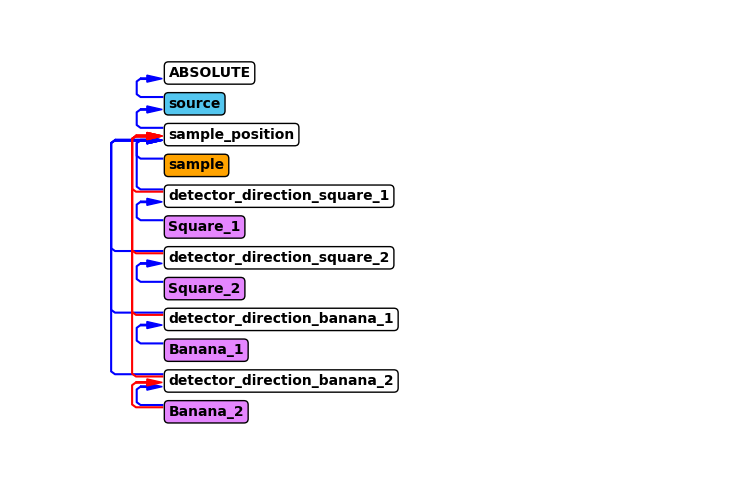

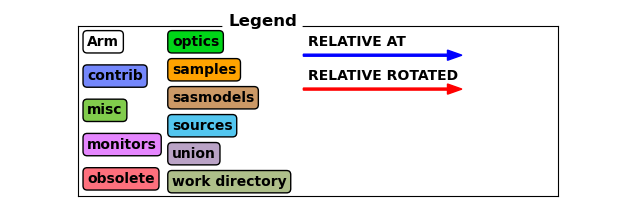

In [5]:
instr.show_diagram()

## Run simulation

In [6]:
data = instr.backengine()


INFO: Using directory: "/home/runner/work/McStasToX/McStasToX/docs/user-guide/test"
INFO: Regenerating c-file: test.c
CFLAGS=
          
 The parameter format of sample is initialized 
 using a static {,,,} vector.
  -> Such static vectors support literal numbers ONLY.
  -> Any vector use of variables or defines must happen via a 
     DECLARE/INITIALIZE pointer.


-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./test.out
lto-wrapper: warning: using serial compilation of 3 LTRANS jobs
lto-wrapper: note: see the '-flto' option documentation for more information
/home/runner/work/McStasToX/McStasToX/.pixi/envs/docs/bin/../libexec/gcc/x86_64-conda-linux-gnu/14.3.0/ld: /tmp/cc52STJs.ltrans1.ltrans.o: in function `read_line_data.part.0.constp

In [7]:
data

[
 McStasDataEvent: Banana_1 with 5543 events. Variables: p th y n id t,
 
 McStasDataEvent: Square_1 with 4175 events. Variables: p x y n id t L,
 
 McStasDataEvent: Banana_2 with 18799 events. Variables: p th y n id t,
 
 McStasDataEvent: Square_2 with 7932 events. Variables: p x y n id t]

## Histogram data to display

In [8]:
hist_data = [mon.make_2d(mon.variables[1], "y") for mon in data]

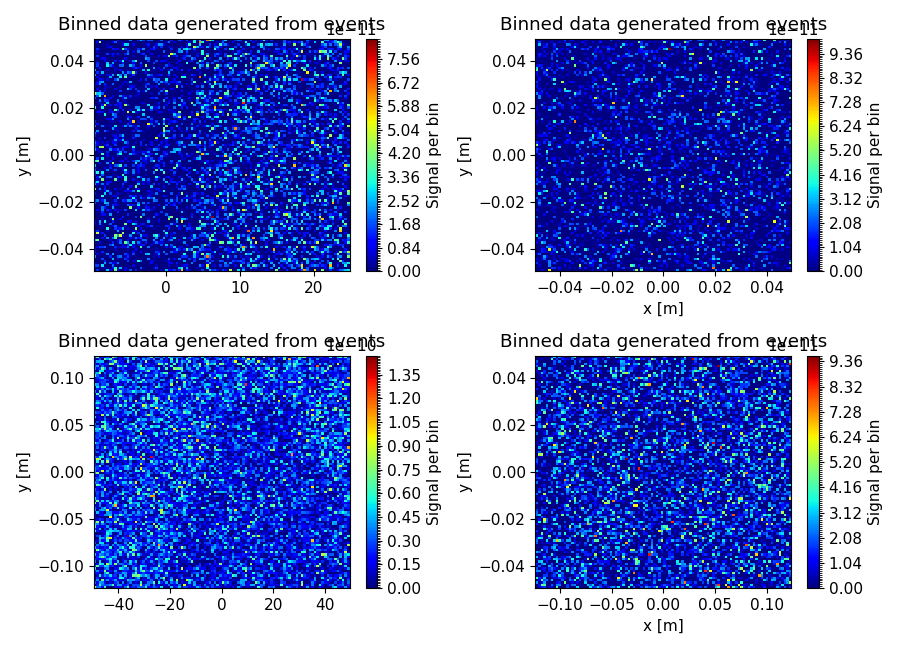

In [9]:
import mcstasscript as ms
ms.make_sub_plot(hist_data)

In [10]:
file_path = data[0].original_data_location
print(file_path)

/home/runner/work/McStasToX/McStasToX/docs/user-guide/test


## Show list of components found in NeXus file

In [11]:
import mcstastox

with mcstastox.Read(file_path) as loaded_data:
    loaded_data.show_components()

All components in file:


2026-04-30 13:35:42,917 INFO:All components in file:


source


2026-04-30 13:35:42,918 INFO:source


sample_position


...

2026-04-30 13:35:42,923 INFO:Banana_1


detector_direction_banana_2


2026-04-30 13:35:42,923 INFO:detector_direction_banana_2


Banana_2


2026-04-30 13:35:42,924 INFO:Banana_2


### Show list of these with available data

In [12]:
with mcstastox.Read(file_path) as loaded_data:
    loaded_data.show_components_with_data()

All components with data in file:


All components with data in file:


2026-04-30 13:35:42,933 INFO:All components with data in file:


Square_1


Square_1


...

Banana_1


2026-04-30 13:35:42,936 INFO:Banana_1


Banana_2


Banana_2


2026-04-30 13:35:42,937 INFO:Banana_2


In [13]:
with mcstastox.Read(file_path) as loaded_data:
    variables = loaded_data.get_component_variables("Square_1")
    print(variables)

p x y n id t L 


### Show list of these with geometry information

In [14]:
with mcstastox.Read(file_path) as loaded_data:
    loaded_data.show_components_with_geometry()

All components with geometry information in file:


All components with geometry information in file:


All components with geometry information in file:


All components with geometry information in file:


2026-04-30 13:35:42,953 INFO:All components with geometry information in file:


...

Banana_2


Banana_2


Banana_2


Banana_2


2026-04-30 13:35:42,961 INFO:Banana_2


### Show monitors with pixel ID's

In [15]:
with mcstastox.Read(file_path) as loaded_data:
    loaded_data.show_components_with_ids()

All components with pixel id information in file:


All components with pixel id information in file:


All components with pixel id information in file:


All components with pixel id information in file:


All components with pixel id information in file:


...

Banana_2


Banana_2


Banana_2


Banana_2


2026-04-30 13:35:42,979 INFO:Banana_2


In [16]:
with mcstastox.Read(file_path) as loaded_data:
    print(loaded_data.get_components_with_ids())

['Square_1', 'Square_2', 'Banana_1', 'Banana_2']


## Get local pixel coordinates for a given component

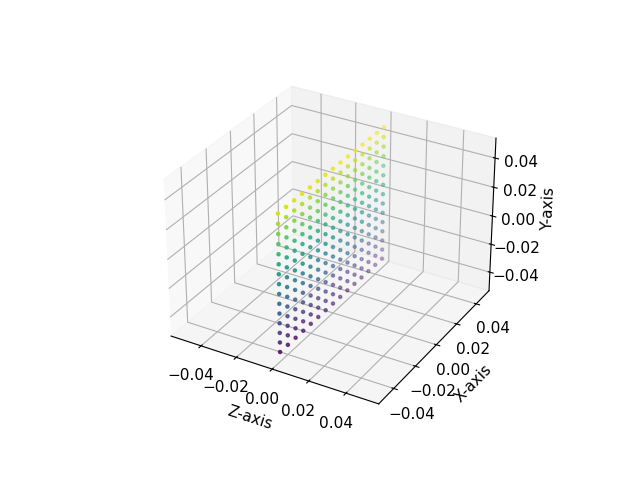

In [17]:
with mcstastox.Read(file_path) as loaded_data:
    coordinates = loaded_data.get_component_local("Square_1")

plot(coordinates)

## Get global coordinates for a given component

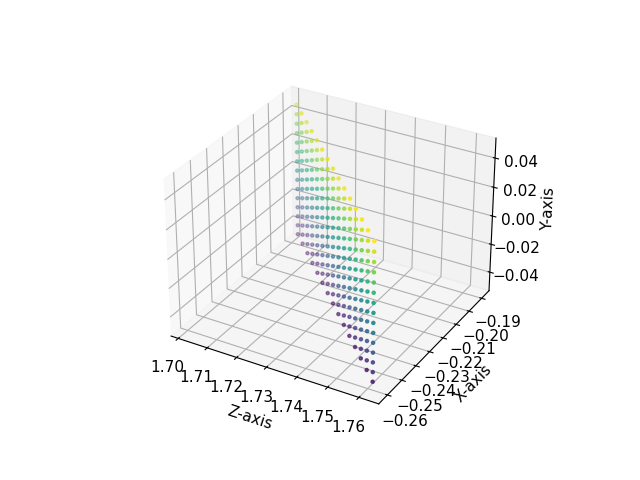

In [18]:
with mcstastox.Read(file_path) as loaded_data:
    coordinates = loaded_data.get_component_global("Square_1")

plot(coordinates)

## Get sample position as well

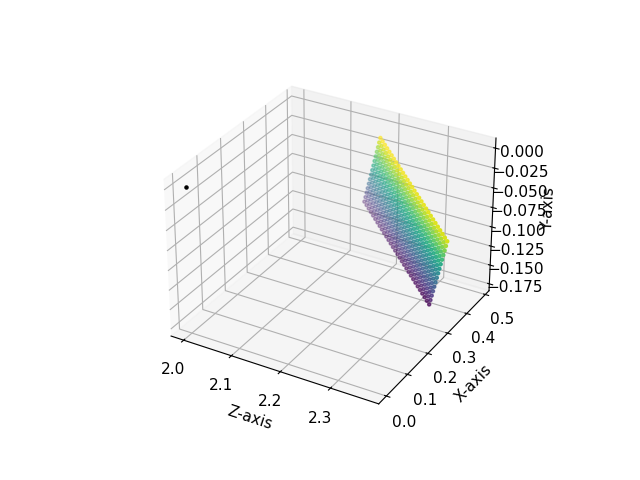

In [19]:
with mcstastox.Read(file_path) as loaded_data:
    coordinates = loaded_data.get_component_global("Square_2")
    sample_pos = loaded_data.get_global_component_coordinates("sample_position")

plot(coordinates, points=[sample_pos])

## Get pixel coordinates for list of monitors

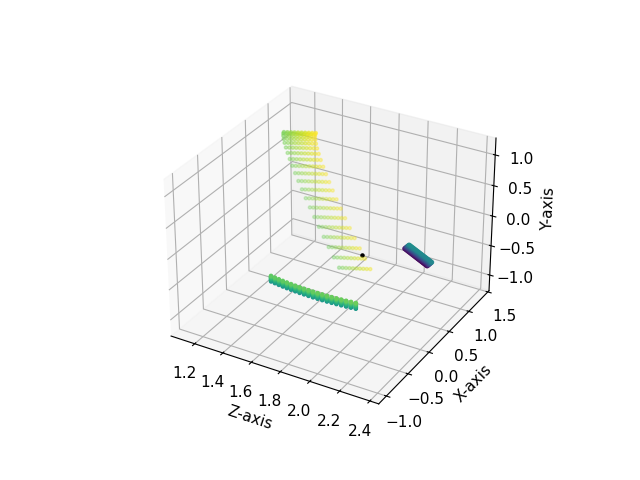

In [20]:
with mcstastox.Read(file_path) as loaded_data:
    coordinates = loaded_data.get_id_to_global_coordinates(component_name=["Square_2", "Banana_1", "Banana_2"])
    sample_pos = loaded_data.get_global_component_coordinates("sample_position")

plot(coordinates, points=[sample_pos])

## Include source and get all pixel coordinates

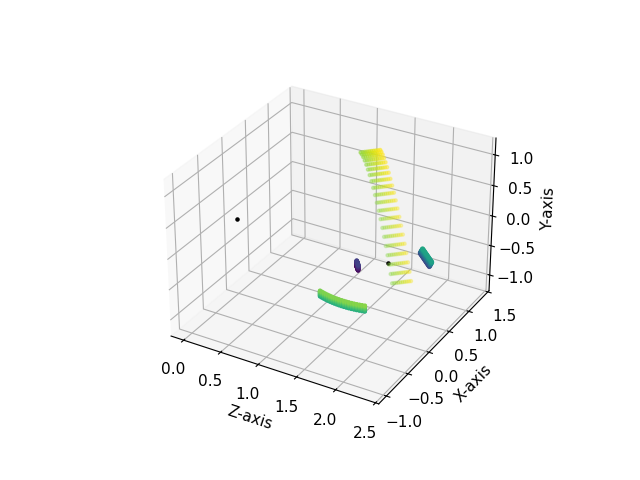

In [21]:
with mcstastox.Read(file_path) as loaded_data:
    coordinates = loaded_data.get_id_to_global_coordinates()
    sample_pos = loaded_data.get_global_component_coordinates("sample_position")
    source_pos = loaded_data.get_global_component_coordinates("source")

plot(coordinates, points=[sample_pos, source_pos])

## Export to (simple) Scipp object

In [22]:
with mcstastox.Read(file_path) as loaded_data:
    scipp_object = loaded_data.export_scipp_simple(source_name="source",
                                                   sample_name="sample_position",
                                                   component_name="Banana_2")

In [23]:
scipp_object

<scipp.DataArray>
Dimensions: Sizes[events:18799, ]
Coordinates:
* position                  vector3              [m]  (events)  [(1.10723, 0.55011, 1.14614), (1.08597, 0.67993, 1.21992), ..., (0.982536, 0.778511, 1.17163), (1.32632, 0.21235, 1.32292)]
* sample_position           vector3              [m]  ()  (0, 0, 2)
* source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.00115242, 0.00161145, ..., 0.00162522, 0.00164246]
Data:
                            float64         [counts]  (events)  [1.9178e-11, 6.34159e-12, ..., 3.98587e-12, 3.27999e-11]

## Plot event positions

In [24]:
import plopp as pp

pp.scatter3d(scipp_object[0::3], pos='position', size=0.02, cbar=True, norm="linear")

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

## Perform coordinate transforms

In [25]:
from scippneutron.conversion.graph.beamline import beamline
from scippneutron.conversion.graph.tof import elastic

# McStas provides absolute time, not time of flight
scipp_object.coords["tof"] = scipp_object.coords["t"]

graph = {**beamline(scatter=True), **elastic("tof")}

In [26]:
scipp_object = scipp_object.transform_coords("dspacing", graph=graph)

In [27]:
scipp_object.hist(dspacing=150).plot(norm="log")

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

# Load all data in simple scipp format

In [28]:
import mcstastox
with mcstastox.Read(file_path) as loaded_data:
    all_data = loaded_data.export_scipp_simple(source_name="source",
                                                   sample_name="sample_position")

all_data

<scipp.DataArray>
Dimensions: Sizes[events:36449, ]
Coordinates:
* position                  vector3              [m]  (events)  [(-0.245404, -0.02, 1.74903), (-0.214762, -0.0133333, 1.72331), ..., (0.982536, 0.778511, 1.17163), (1.32632, 0.21235, 1.32292)]
* sample_position           vector3              [m]  ()  (0, 0, 2)
* source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.000762838, 0.00116951, ..., 0.00162522, 0.00164246]
Data:
                            float64         [counts]  (events)  [3.50489e-12, 1.32209e-11, ..., 3.98587e-12, 3.27999e-11]

In [29]:
pp.scatter3d(all_data[0::3], pos='position', size=0.02, cbar=True, norm="log")

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

## Convert to d-space and compare
Lets compare data from all the detectors with the previous scipp object that only contained one.

In [30]:
all_data.coords["tof"] = all_data.coords["t"]
all_data = all_data.transform_coords("dspacing", graph=graph)

pp.plot({"Only banana 2": scipp_object.hist(dspacing=200),
         "All data": all_data.hist(dspacing=200)}, norm="log")

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Also access to data directly
Its possible to get access to the data directly if necessary, this is demonstrated here.

In [31]:
with mcstastox.Read(file_path) as loaded_data:
    raw_event_data = loaded_data.get_event_data(variables=["id", "t"], component_name="Square_2")
    pos, rot = loaded_data.get_component_placement(component_name="Square_2")

print("Raw event data")
print(raw_event_data["id"])
print(raw_event_data["t"])

print("Component placement")
print(pos)
print(rot)

Raw event data
[555. 357. 228. ... 355. 377. 594.]
[0.00122248 0.00078535 0.00114255 ... 0.00108291 0.00110442 0.00116819]
Component placement
[ 0.41933528 -0.09313876  2.25589664]
[[ 0.54463904  0.28684223 -0.78809254]
 [-0.          0.93969262  0.34202014]
 [ 0.83867057 -0.18627752  0.51179328]]


In [32]:
with mcstastox.Read(file_path) as loaded_data:
    raw_event_data = loaded_data.get_event_data(variables=["id", "t", "L"], component_name="Square_1")

## Add additional data to a scipp object
We can add data read directly to the scipp object, here the actual wavelength recorded by McStas.

In [33]:
import scipp as sc

with mcstastox.Read(file_path) as loaded_data:
    sq1 = loaded_data.export_scipp_simple(source_name="source", sample_name="sample_position", component_name="Square_1")

sq1.coords["sim_wavelength"] = sc.array(dims=["events"], values=raw_event_data["L"], unit="Å")

sq1.coords["tof"] = sq1.coords["t"]
sq1 = sq1.transform_coords("wavelength", graph=graph)
sq1.coords["wavelength_ratio"] = (sq1.coords["sim_wavelength"] - sq1.coords["wavelength"])/sq1.coords["sim_wavelength"]

In [34]:
sq1

<scipp.DataArray>
Dimensions: Sizes[events:4175, ]
Coordinates:
  L1                        float64              [m]  ()  2
  L2                        float64              [m]  (events)  [0.351584, 0.350508, ..., 0.352594, 0.350571]
  Ltotal                    float64              [m]  (events)  [2.35158, 2.35051, ..., 2.35259, 2.35057]
  incident_beam             vector3              [m]  ()  (0, 0, 2)
  position                  vector3              [m]  (events)  [(-0.245404, -0.02, 1.74903), (-0.214762, -0.0133333, 1.72331), ..., (-0.25051, -0.0266667, 1.75331), (-0.224976, 0.02, 1.73188)]
  sample_position           vector3              [m]  ()  (0, 0, 2)
  scattered_beam            vector3              [m]  (events)  [(-0.245404, -0.02, -0.250975), (-0.214762, -0.0133333, -0.276686), ..., (-0.25051, -0.0266667, -0.246689), (-0.224976, 0.02, -0.268116)]
* sim_wavelength            float64             [Å]  (events)  [1.28488, 1.97383, ..., 2.0056, 1.52112]
  source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.000762838, 0.00116951, ..., 0.00118902, 0.000906942]
  tof                       float64              [s]  (events)  [0.000762838, 0.00116951, ..., 0.00118902, 0.000906942]
* wavelength                float64             [Å]  (events)  [1.28331, 1.96835, ..., 1.99941, 1.52639]
* wavelength_ratio          float64  [dimensionless]  (events)  [0.00121821, 0.00277912, ..., 0.00308725, -0.0034682]
Data:
                            float64         [counts]  (events)  [3.50489e-12, 1.32209e-11, ..., 5.34599e-11, 8.1301e-12]

## Plotting comparison between actual and calculated wavelength

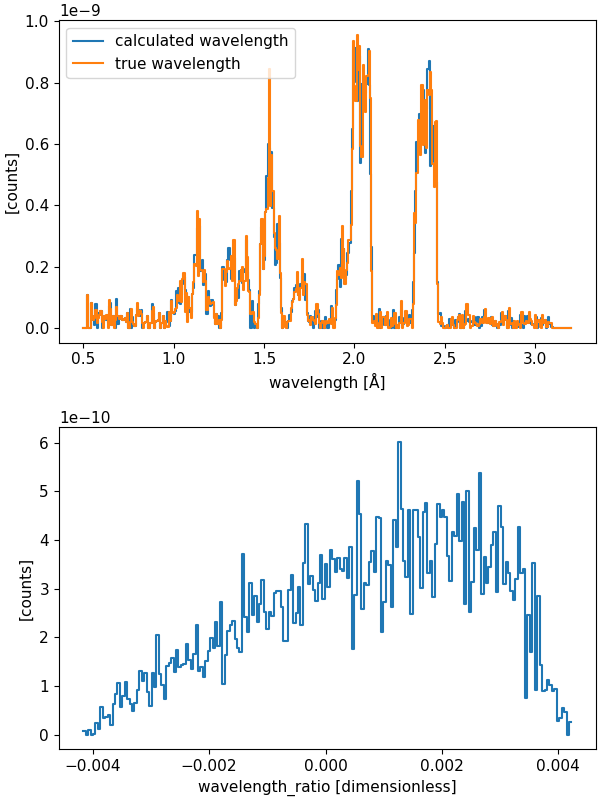

In [35]:
w_start = 0.5
w_end=3.2
w_steps=401
wavs = sc.linspace("wavelength", w_start, w_end, w_steps, unit="angstrom")
sim_wavs = sc.linspace("sim_wavelength", w_start, w_end, w_steps, unit="angstrom")

pp.plot({
    "calculated wavelength": sq1.hist(wavelength=wavs),
    "true wavelength": sq1.hist(sim_wavelength=sim_wavs).rename(sim_wavelength="wavelength")
}) / sq1.hist(wavelength_ratio=200).plot()